
# LSTM Autoencoder for Network Anomaly Detection (PyTorch)
Full example with synthetic Modbus-like traffic data

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# ============================================================
# 1. GENERATE FAKE DATA
# ============================================================

NUM_PACKETS = 20000

def generate_clean_traffic(n):
    """Simulate normal Modbus traffic"""
    data = {
        "rtt": np.random.normal(5.0, 1.5, n).clip(1, 20),
        "packet_length": np.random.normal(100, 15, n).clip(60, 200),
        "inter_arrival": np.random.exponential(0.5, n).clip(0.01, 5),
        "payload_size": np.random.normal(50, 10, n).clip(10, 150),
        "function_code": np.random.choice([1, 2, 3, 4, 5, 6], n).astype(float),
    }
    return np.column_stack(list(data.values()))

def generate_mitm_traffic(n):
    """Simulate MITM traffic with oscillating RTT and mixed clean packets"""
    data = generate_clean_traffic(n)

    mitm_mask = np.zeros(n, dtype=bool)
    chunk_starts = [2000, 5000, 8000, 12000, 16000]
    for start in chunk_starts:
        end = min(start + 2500, n)
        mitm_mask[start:end] = True

    t = np.arange(n)
    oscillation = 3.0 * np.sin(2 * np.pi * t / 200)
    data[mitm_mask, 0] += oscillation[mitm_mask] + 4.0
    data[mitm_mask, 1] += np.random.normal(20, 5, mitm_mask.sum())
    data[mitm_mask, 2] += np.random.normal(0.3, 0.1, mitm_mask.sum())

    return data, mitm_mask

print("Generating synthetic data...")
clean_data = generate_clean_traffic(NUM_PACKETS)
mitm_data, mitm_mask = generate_mitm_traffic(NUM_PACKETS)

print(f"Clean data shape: {clean_data.shape}")
print(f"MITM data shape:  {mitm_data.shape}")
print(f"MITM packets:     {mitm_mask.sum()} / {NUM_PACKETS} ({mitm_mask.mean()*100:.0f}%)")

Generating synthetic data...
Clean data shape: (20000, 5)
MITM data shape:  (20000, 5)
MITM packets:     12500 / 20000 (62%)


In [4]:
# ============================================================
# 2. NORMALIZE
# ============================================================

scaler = MinMaxScaler()
clean_scaled = scaler.fit_transform(clean_data)
mitm_scaled = scaler.transform(mitm_data)

In [5]:
# ============================================================
# 3. CREATE SLIDING WINDOWS
# ============================================================

WINDOW_SIZE = 50

def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size):
        windows.append(data[i : i + window_size])
    return np.array(windows)

X_clean = create_windows(clean_scaled, WINDOW_SIZE)
X_mitm = create_windows(mitm_scaled, WINDOW_SIZE)

window_labels = np.array([
    mitm_mask[i : i + WINDOW_SIZE].mean() > 0.5
    for i in range(len(mitm_mask) - WINDOW_SIZE)
]).astype(int)

# Train/val split
split = int(0.9 * len(X_clean))
X_train = X_clean[:split]
X_val = X_clean[split:]

print(f"\nTrain windows: {X_train.shape}")
print(f"Val windows:   {X_val.shape}")
print(f"MITM windows:  {X_mitm.shape}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
X_mitm_t = torch.FloatTensor(X_mitm).to(device)
X_clean_t = torch.FloatTensor(X_clean).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, X_train_t),
    batch_size=64,
    shuffle=True,
)



Train windows: (17955, 50, 5)
Val windows:   (1995, 50, 5)
MITM windows:  (19950, 50, 5)


In [6]:
# ============================================================
# 4. LSTM AUTOENCODER MODEL
# ============================================================

class LSTMAutoencoder(nn.Module):
    def __init__(self, num_features, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.num_features = num_features
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_l1 = nn.LSTM(num_features, hidden_dim, batch_first=True)
        self.encoder_l2 = nn.LSTM(hidden_dim, latent_dim, batch_first=True)

        # Decoder
        self.decoder_l1 = nn.LSTM(latent_dim, latent_dim, batch_first=True)
        self.decoder_l2 = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, num_features)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        # Encode
        x, _ = self.encoder_l1(x)
        x = torch.relu(x)
        _, (hidden, cell) = self.encoder_l2(x)

        # Latent vector → repeat for decoder
        latent = hidden.squeeze(0)  # (batch, latent_dim)
        decoder_input = latent.unsqueeze(1).repeat(1, seq_len, 1)  # (batch, seq_len, latent_dim)

        # Decode
        x, _ = self.decoder_l1(decoder_input)
        x = torch.relu(x)
        x, _ = self.decoder_l2(x)
        x = torch.relu(x)
        x = self.output_layer(x)

        return x

NUM_FEATURES = 5
model = LSTMAutoencoder(NUM_FEATURES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 64,581


In [7]:
# ============================================================
# 5. TRAIN
# ============================================================

EPOCHS = 30
train_losses = []
val_losses = []

print("\nTraining on clean data only...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t)
        val_loss = criterion(val_output, X_val_t).item()
        val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}")



Training on clean data only...
Epoch   5/30 | Train Loss: 0.037514 | Val Loss: 0.038452
Epoch  10/30 | Train Loss: 0.037512 | Val Loss: 0.038504
Epoch  15/30 | Train Loss: 0.037091 | Val Loss: 0.037866
Epoch  20/30 | Train Loss: 0.035357 | Val Loss: 0.035543
Epoch  25/30 | Train Loss: 0.033756 | Val Loss: 0.034350
Epoch  30/30 | Train Loss: 0.032652 | Val Loss: 0.033256


In [8]:
# ============================================================
# 6. COMPUTE RECONSTRUCTION ERROR
# ============================================================

def get_reconstruction_error(model, data):
    model.eval()
    with torch.no_grad():
        reconstructed = model(data)
        mse = torch.mean((data - reconstructed) ** 2, dim=(1, 2))
    return mse.cpu().numpy()

print("\nComputing reconstruction errors...")
clean_errors = get_reconstruction_error(model, X_clean_t)
mitm_errors = get_reconstruction_error(model, X_mitm_t)


Computing reconstruction errors...


In [9]:
# ============================================================
# 7. SET THRESHOLD & EVALUATE
# ============================================================

threshold = np.percentile(clean_errors, 95)
predictions = (mitm_errors > threshold).astype(int)

tp = ((predictions == 1) & (window_labels == 1)).sum()
fp = ((predictions == 1) & (window_labels == 0)).sum()
tn = ((predictions == 0) & (window_labels == 0)).sum()
fn = ((predictions == 0) & (window_labels == 1)).sum()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*40}")
print(f"RESULTS")
print(f"{'='*40}")
print(f"Threshold:  {threshold:.6f}")
print(f"Precision:  {precision:.3f}")
print(f"Recall:     {recall:.3f}")
print(f"F1 Score:   {f1:.3f}")
print(f"TP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")


RESULTS
Threshold:  0.038031
Precision:  0.957
Recall:     0.998
F1 Score:   0.977
TP: 12472  FP: 560  TN: 6895  FN: 23


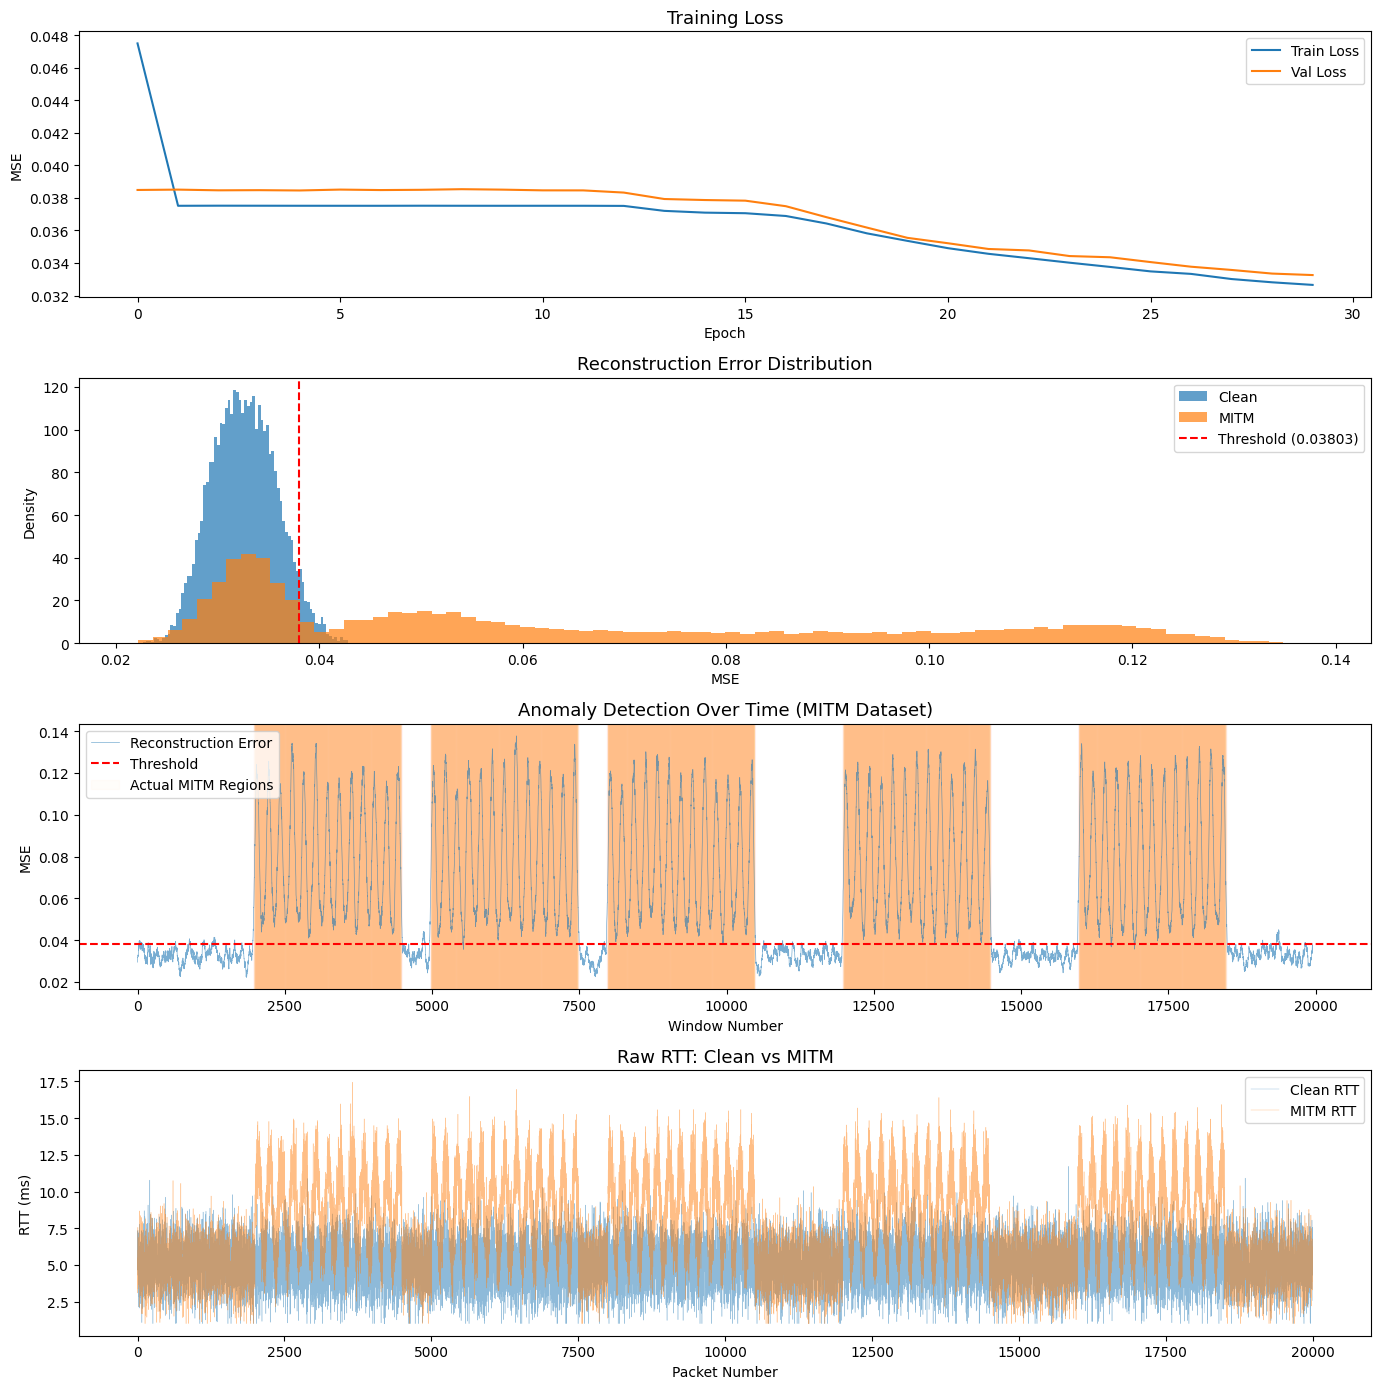


Done! Check lstm_ae_results.png


In [10]:
# ============================================================
# 8. VISUALIZE
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# Plot 1: Training loss
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses, label="Val Loss")
axes[0].set_title("Training Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

# Plot 2: Error distribution
axes[1].hist(clean_errors, bins=80, alpha=0.7, label="Clean", density=True)
axes[1].hist(mitm_errors, bins=80, alpha=0.7, label="MITM", density=True)
axes[1].axvline(threshold, color="red", linestyle="--", label=f"Threshold ({threshold:.5f})")
axes[1].set_title("Reconstruction Error Distribution", fontsize=13)
axes[1].set_xlabel("MSE")
axes[1].set_ylabel("Density")
axes[1].legend()

# Plot 3: Error over time with ground truth
axes[2].plot(mitm_errors, alpha=0.6, linewidth=0.5, label="Reconstruction Error")
axes[2].axhline(threshold, color="red", linestyle="--", label="Threshold")
# Shade actual MITM regions
ymin, ymax = axes[2].get_ylim()
for i in range(len(window_labels)):
    if window_labels[i] == 1:
        axes[2].axvspan(i, i + 1, alpha=0.02, color="orange")
axes[2].set_title("Anomaly Detection Over Time (MITM Dataset)", fontsize=13)
axes[2].set_xlabel("Window Number")
axes[2].set_ylabel("MSE")
axes[2].legend(["Reconstruction Error", "Threshold", "Actual MITM Regions"])

# Plot 4: Raw RTT comparison
axes[3].plot(clean_data[:, 0], alpha=0.5, linewidth=0.3, label="Clean RTT")
axes[3].plot(mitm_data[:, 0], alpha=0.5, linewidth=0.3, label="MITM RTT")
axes[3].set_title("Raw RTT: Clean vs MITM", fontsize=13)
axes[3].set_xlabel("Packet Number")
axes[3].set_ylabel("RTT (ms)")
axes[3].legend()

plt.tight_layout()
plt.savefig("lstm_ae_results.png", dpi=150)
plt.show()

print("\nDone! Check lstm_ae_results.png")